# 4월 21일 실습 (2026-04-21)

## 👨‍🏫 Senior Mentor's Guide
(수업 중 진행되는 내용에 따라 업데이트될 예정입니다.)

---

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 시각화 설정
sns.set_theme(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False
%config InlineBackend.figure_format = 'retina'

print("✅ 분석 라이브러리 로드 완료.")

✅ 분석 라이브러리 로드 완료.


In [2]:
df = pd.read_csv('content/temperatures.csv')

df['Date1'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

(
    df.info(),
    df['Date1'].dt.strftime('%Y-%m').head(1),
    df['Date1'].dt.dayofweek.head(1),
    (df['Date1'] + pd.Timedelta(days=1)).head(1),
    (df['Date1'] + pd.DateOffset(month=1)).head(1),
    (df['Date1'] + pd.DateOffset(months=1)).head(1),
    (df['Date1'] - pd.DateOffset(years=1)).head(1),
    df['Temp'].rolling(3, min_periods=1).mean().head(3)
)

<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3650 non-null   str           
 1   Temp    3650 non-null   float64       
 2   Date1   3650 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 121.3 KB


/tmp/ipykernel_30899/4147329172.py:10: PerformanceWarning: Non-vectorized DateOffset being applied to Series or DatetimeIndex.
  (df['Date1'] + pd.DateOffset(month=1)).head(1),


(None,
 0    1981-01
 Name: Date1, dtype: str,
 0    3
 Name: Date1, dtype: int32,
 0   1981-01-02
 Name: Date1, dtype: datetime64[us],
 0   1981-01-01
 Name: Date1, dtype: datetime64[us],
 0   1981-02-01
 Name: Date1, dtype: datetime64[us],
 0   1980-01-01
 Name: Date1, dtype: datetime64[us],
 0    20.700000
 1    19.300000
 2    19.133333
 Name: Temp, dtype: float64)

In [3]:
ttc = pd.read_csv('content/titanic_train.csv')

(
    ttc['Age'].apply(lambda x: 1 if x >= 19 else 0).head(1),
    ttc[ttc['Name'].str.contains('Miss')].head(1),
    pd.pivot_table(ttc, index='Pclass', columns='Sex', values='Survived', aggfunc='mean', margins=True),
    pd.pivot_table(ttc, index=['Pclass', 'Sex'], columns=['Survived', 'Embarked'], values=['Age'])
)

(0    1
 Name: Age, dtype: int64,
    PassengerId  Survived  Pclass                    Name     Sex   Age  SibSp  \
 2            3         1       3  Heikkinen, Miss. Laina  female  26.0      0   
 
    Parch            Ticket   Fare Cabin Embarked  
 2      0  STON/O2. 3101282  7.925   NaN        S  ,
 Sex       female      male       All
 Pclass                              
 1       0.968085  0.368852  0.629630
 2       0.921053  0.157407  0.472826
 3       0.500000  0.135447  0.242363
 All     0.742038  0.188908  0.383838,
                      Age                                                  
 Survived               0                                1                 
 Embarked               C          Q          S          C     Q          S
 Pclass Sex                                                                
 1      female  50.000000        NaN  13.500000  35.675676  33.0  33.619048
        male    43.050000  44.000000  45.362500  36.437500   NaN  36.121667
 2      fe

**3) pivot_table VS groupby**

| **기능**       | **`pd.pivot_table`**       | **`groupby`**           |
|---------------|---------------------------|-------------------------|
| **목적**      | 행, 열, 값으로 다차원 분석       | 주로 그룹화 및 집계        |
| **출력 형태**   | 피벗 테이블 형태의 `DataFrame` | 그룹화된 `DataFrame` 또는 `Series` |
| **다중 집계 함수** | 지원 (`aggfunc`로 여러 함수 가능) | `agg()`로 여러 함수 가능   |
| **margins 옵션** | 전체 합/평균 등 추가 가능       | 지원하지 않음             |
| **다중 인덱스**   | 행과 열에 다중 인덱스 생성       | 행에만 다중 인덱스 생성      |
| **사용성**     | 행과 열을 동시에 요약 가능       | 주로 행 기준으로 요약      |


In [4]:
pop01 = pd.read_csv('content/seoul_pop_01.csv')
pop02 = pd.read_csv('content/seoul_pop_02.csv')
pop03 = pd.read_csv('content/seoul_pop_03.csv')

pop = pd.merge(left=pd.merge(left=pop01, right=pop02, on='year', how='inner'), right=pop03, on='year', how='inner')


pop['k_total'] = pop['k_male'] + pop['k_female']
pop['f_total'] = pop['f_male'] + pop['f_female']
pop['male'] = pop['k_male'] + pop['f_male']
pop['female'] = pop['k_female'] + pop['f_female']
pop['total'] = pop['k_total'] + pop['f_total']

pop = pop[['year', 'household', 'total', 'male', 'female', 'k_total', 'k_male', 'k_female', 'f_total', 'f_male', 'f_female', 'older_65']]
pop.head()

,year,household,total,male,female,k_total,k_male,k_female,f_total,f_male,f_female,older_65
0,1985,2338,8364,4167,4197,8351,4160,4191,13,7,6,211
1,1986,2428,9799,4906,4893,9787,4899,4888,12,7,5,305
2,1987,2518,9990,5006,4984,9979,5000,4979,11,6,5,329
3,1988,2658,10286,5161,5125,10276,5156,5120,10,5,5,349
4,1989,2817,10577,5311,5266,10566,5305,5261,11,6,5,363


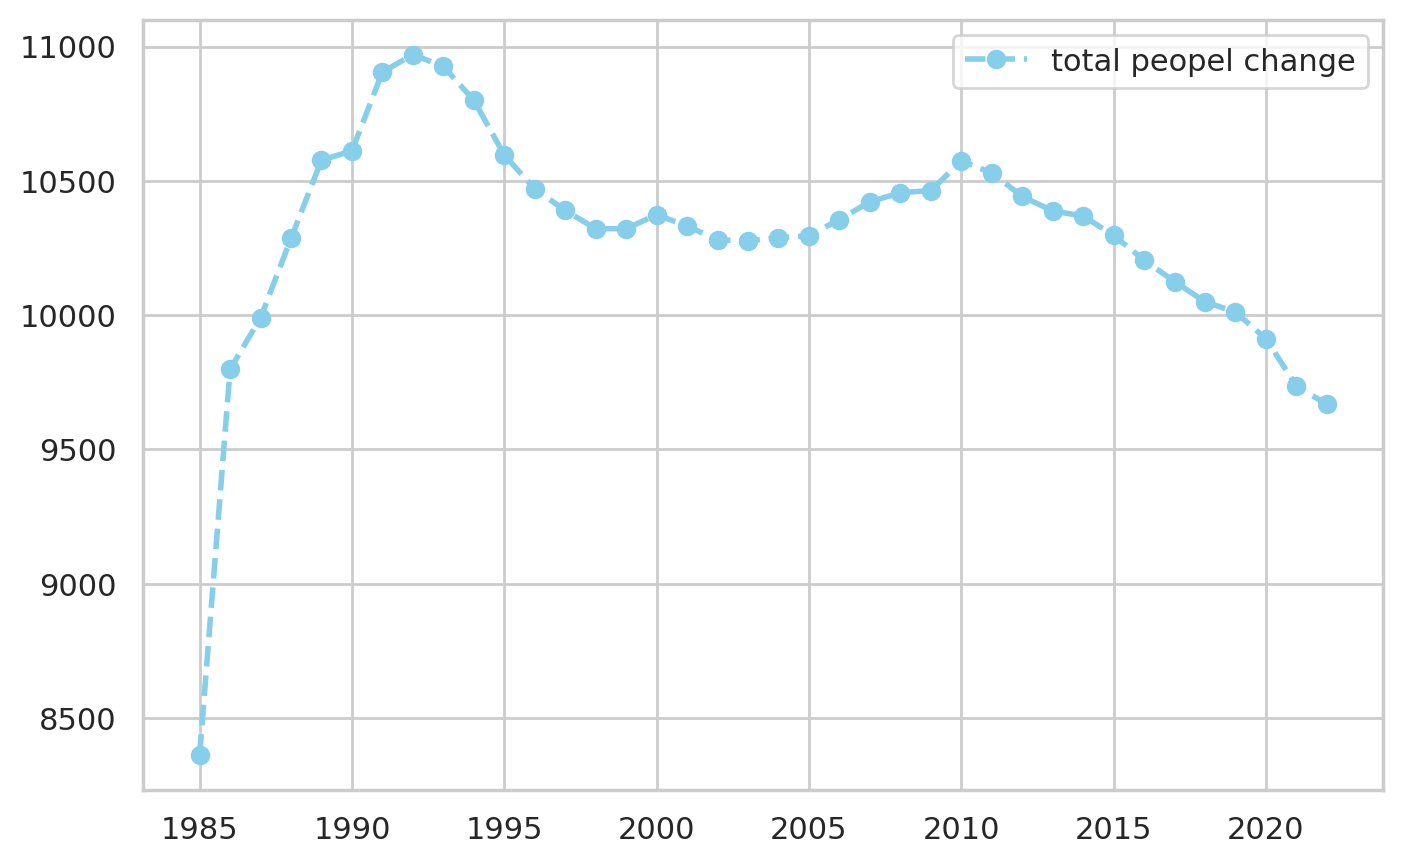

In [8]:
plt.figure(figsize=(8,5))

plt.plot(pop['year'], pop['total'], 
         color='skyblue',      # 선 색상
         linestyle='--',       # 점선 모양
         linewidth=2,          # 선 굵기
         marker='o',           # 데이터 포인트 모양 (원형)
        #  markersize=8,         # 마커 크기
         label='total peopel change'
) 
plt.legend()
plt.show()

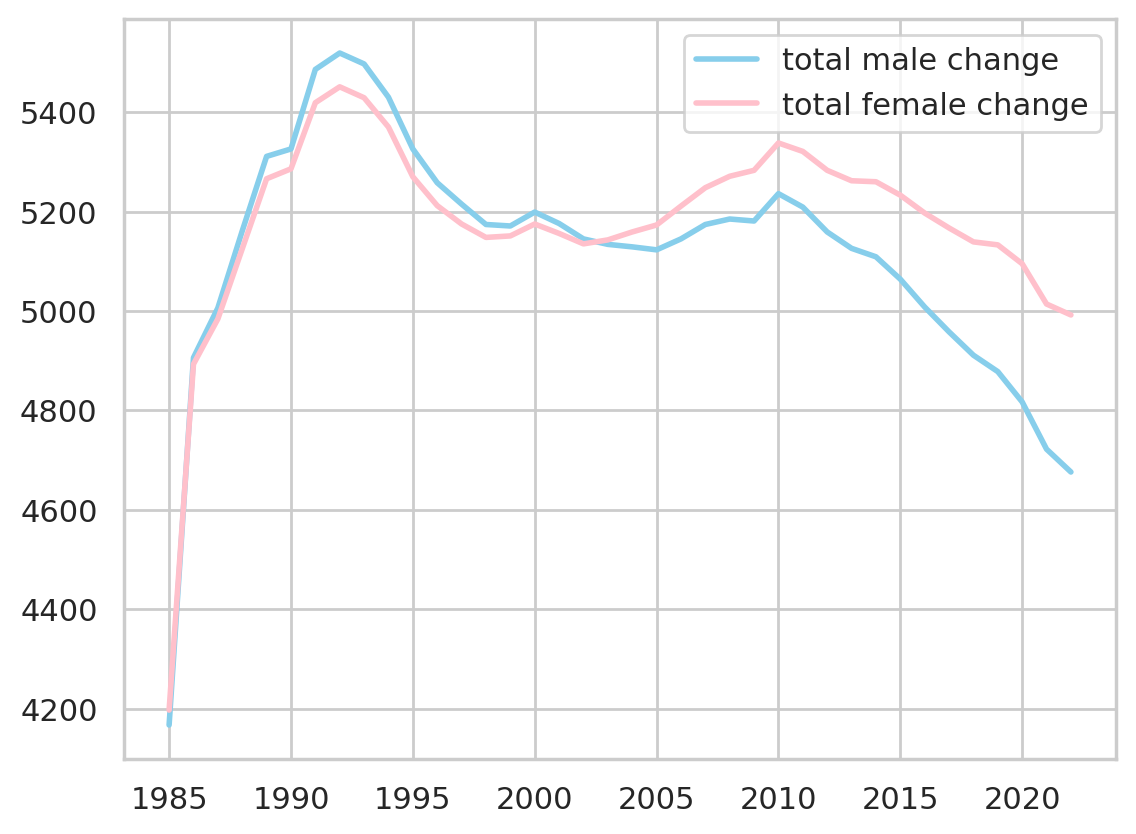

In [12]:
plt.plot(pop['year'], pop['male'], 
         color='skyblue',      # 선 색상
         linestyle='-',       # 점선 모양
         linewidth=2,          # 선 굵기
         label='total male change'
) 
plt.plot(pop['year'], pop['female'], 
         color='pink',      # 선 색상
         linestyle='-',       # 점선 모양
         linewidth=2,          # 선 굵기
         label='total female change'
) 
plt.legend()
plt.show()

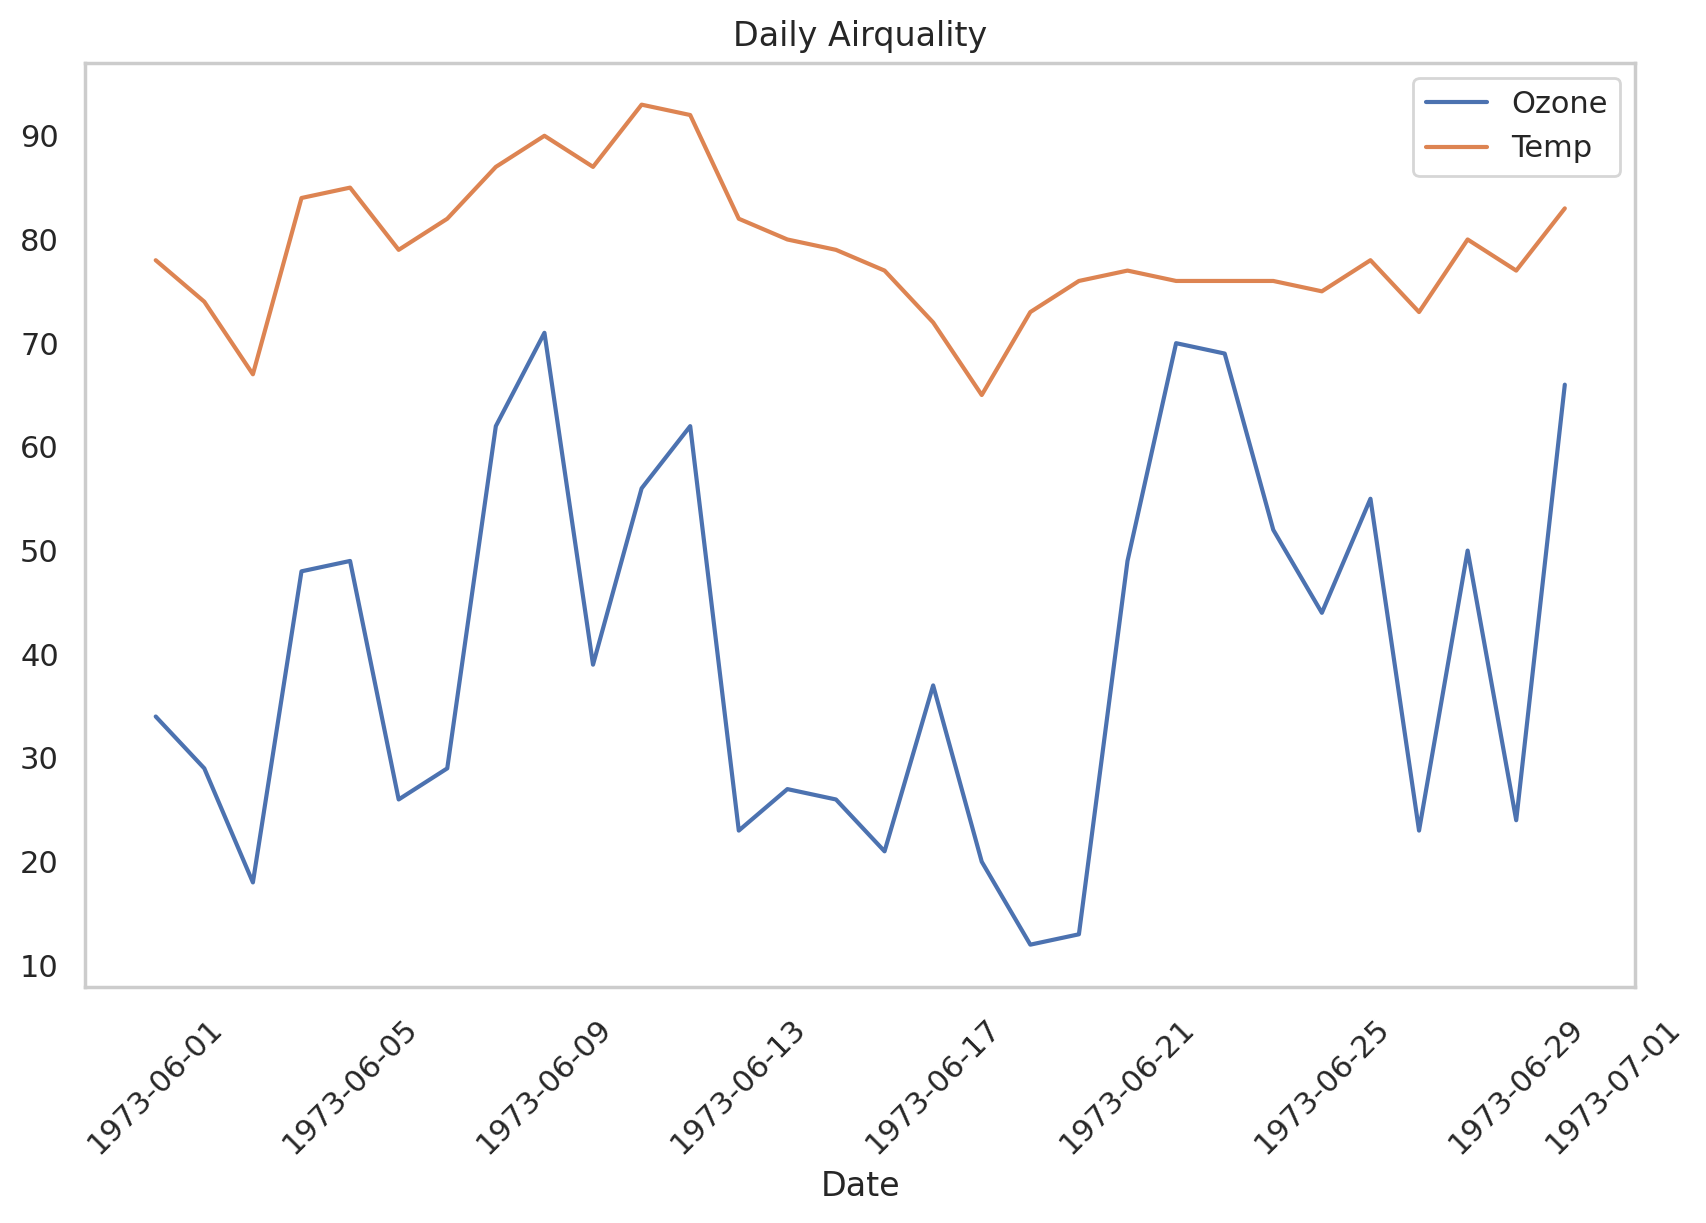

In [28]:
air2 = pd.read_csv('content/airquality_simple2.csv').drop('Unnamed: 0', axis=1)
air2['Date'] = pd.to_datetime(air2['Date'])

plt.figure(figsize=(10,6))
plt.plot(air2['Date'], air2['Ozone'],
    label = "Ozone"
)
plt.plot(air2['Date'], air2['Temp'],
    label = "Temp"
)
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.title("Daily Airquality")
plt.legend()
plt.grid()
plt.show()


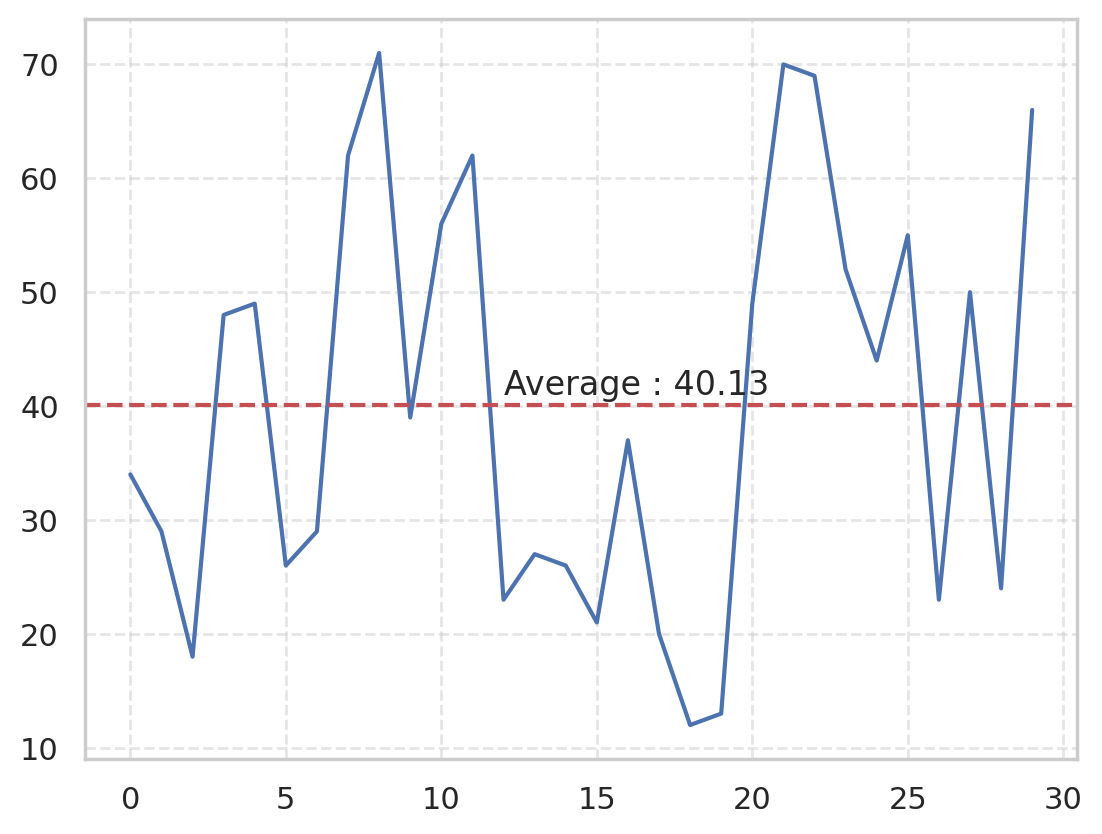

In [42]:
ozone_mean = air2['Ozone'].mean()

plt.plot(air2['Ozone'])
plt.axhline(ozone_mean, color='r', linestyle='--')
# plt.text(12, 41, ozone_mean)
plt.text(12, 41, f'Average : {ozone_mean:.2f}')
plt.grid(linestyle='--', alpha=0.5)

plt.show()

In [54]:
titanic = sns.load_dataset('titanic')
iris = sns.load_dataset('iris')
tips = sns.load_dataset('tips')
(
    sns.get_dataset_names(),
    titanic,
)

(['anagrams',
  'anscombe',
  'attention',
  'brain_networks',
  'car_crashes',
  'diamonds',
  'dots',
  'dowjones',
  'exercise',
  'flights',
  'fmri',
  'geyser',
  'glue',
  'healthexp',
  'iris',
  'mpg',
  'penguins',
  'planets',
  'seaice',
  'taxis',
  'tips',
  'titanic'],
      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
 0           0       3    male  22.0      1      0   7.2500        S   Third   
 1           1       1  female  38.0      1      0  71.2833        C   First   
 2           1       3  female  26.0      0      0   7.9250        S   Third   
 3           1       1  female  35.0      1      0  53.1000        S   First   
 4           0       3    male  35.0      0      0   8.0500        S   Third   
 ..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
 886         0       2    male  27.0      0      0  13.0000        S  Second   
 887         1       1  female  19.0      0      0  30.0000        S   Firs

- histplot( ) 함수의 매개변수

    - data : 히스토그램을 그릴 데이터셋을 지정

    - bins : 히스토그램에서 막대의 개수를 지정

    - kde : True로 설정하면 커널 밀도 추정(KDE) 곡선을 히스토그램 위에 추가
- 히스토그램
    - 연속형 데이터를 일정한 간격으로 나누어 각 구간에 속하는 데이터 빈도를 막대로 표현한 그래프
    - 각 막대는 데이터 분포를 나타내며 높이는 해당 구간의 데이터 개수를 나타낸다.

- 커널 밀도 추정 그래프
    - 데이터 분포를 나타낸다는 점에서 히스토그램과 비슷하다.
    - 그러나 막대 그래프 대신 부드러운 곡선을 사용하는데, 이는 커널 함수 덕분에 가능하다.
    - 커널 함수는 각 데이터 포인트 주위에 작은 확률 분포를 만들고, 이를 모두 합하여 전체 데이터의 분포를 표현한다.

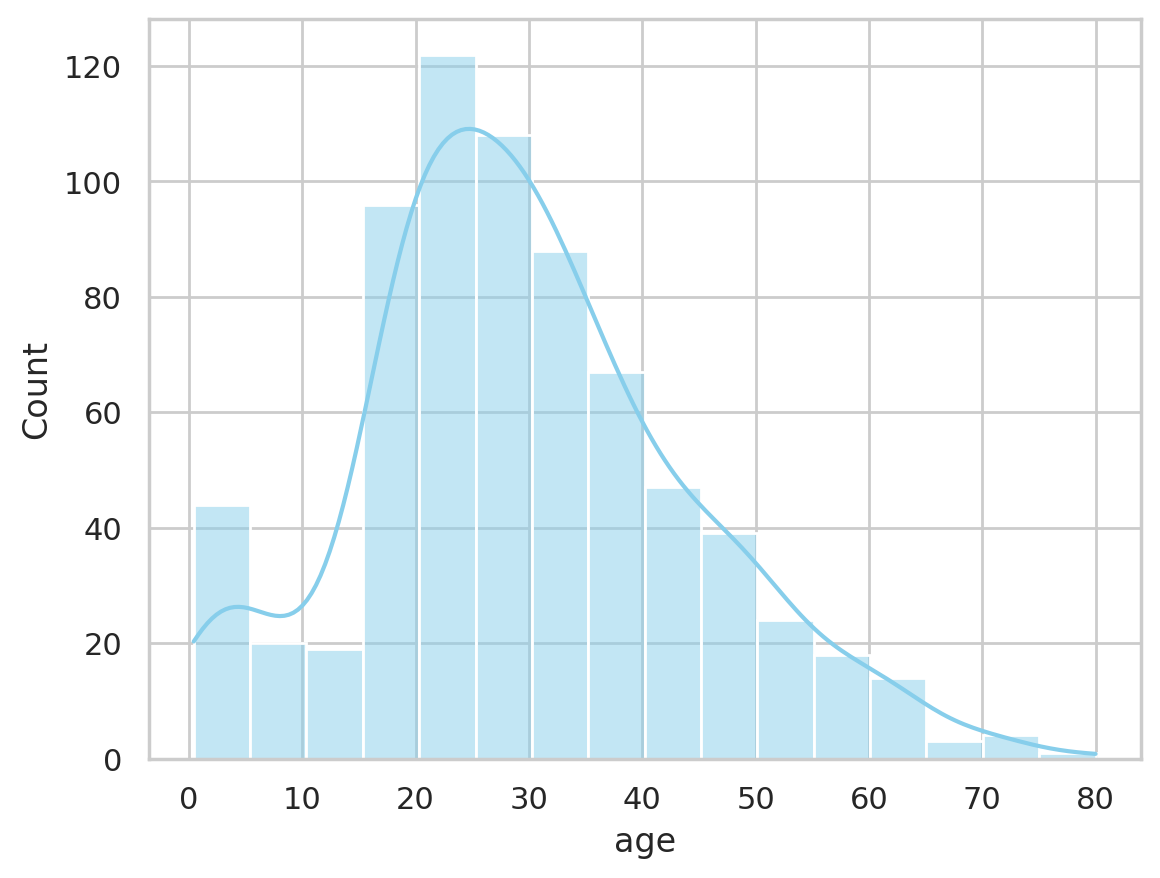

In [50]:
sns.histplot(data=titanic['age'], bins=16, kde=True, color='skyblue')
plt.show()

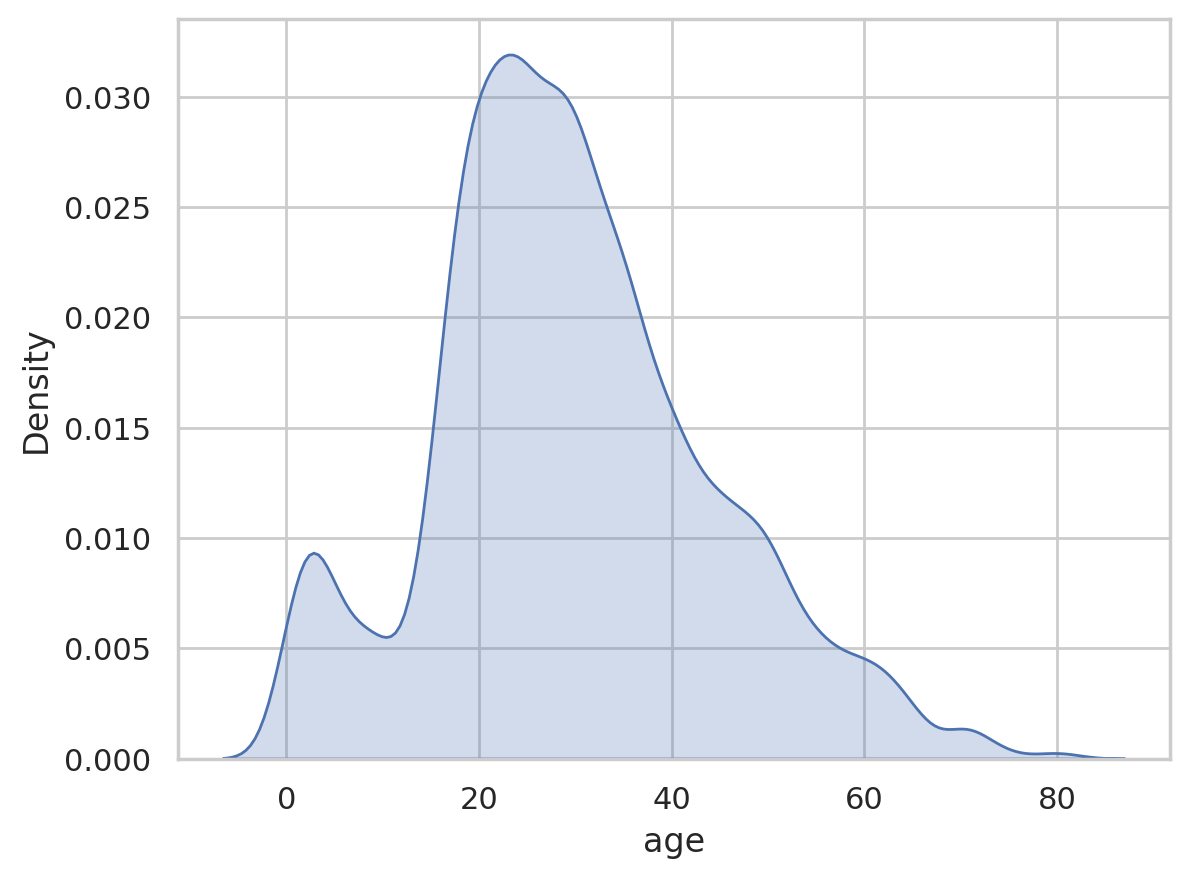

In [51]:
sns.kdeplot(data=titanic, x='age', fill=True, bw_adjust=0.6)
plt.show()

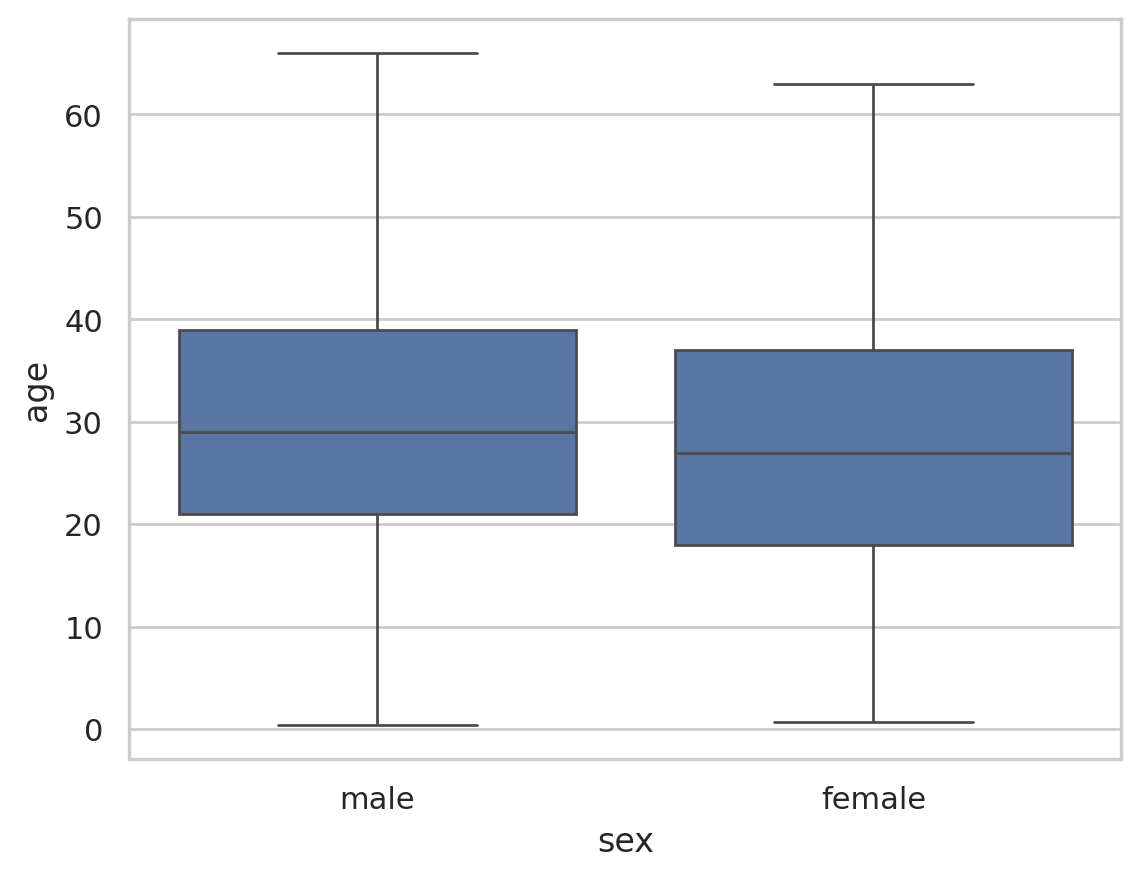

In [52]:
sns.boxplot(data=titanic, x='sex', y='age', showfliers=False)   # showfliers
plt.show()

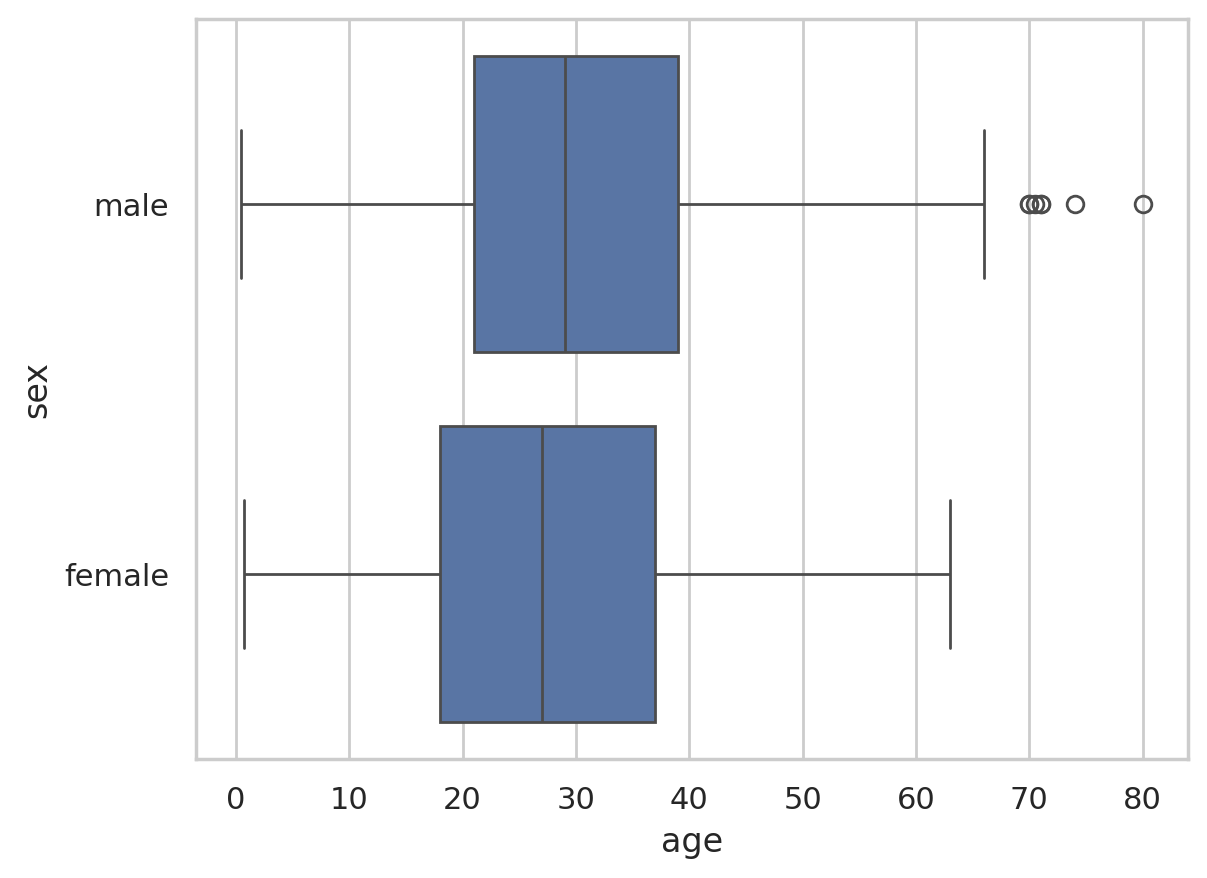

In [55]:
sns.boxplot(data=titanic, y='sex', x='age', orient='h') 
plt.show()

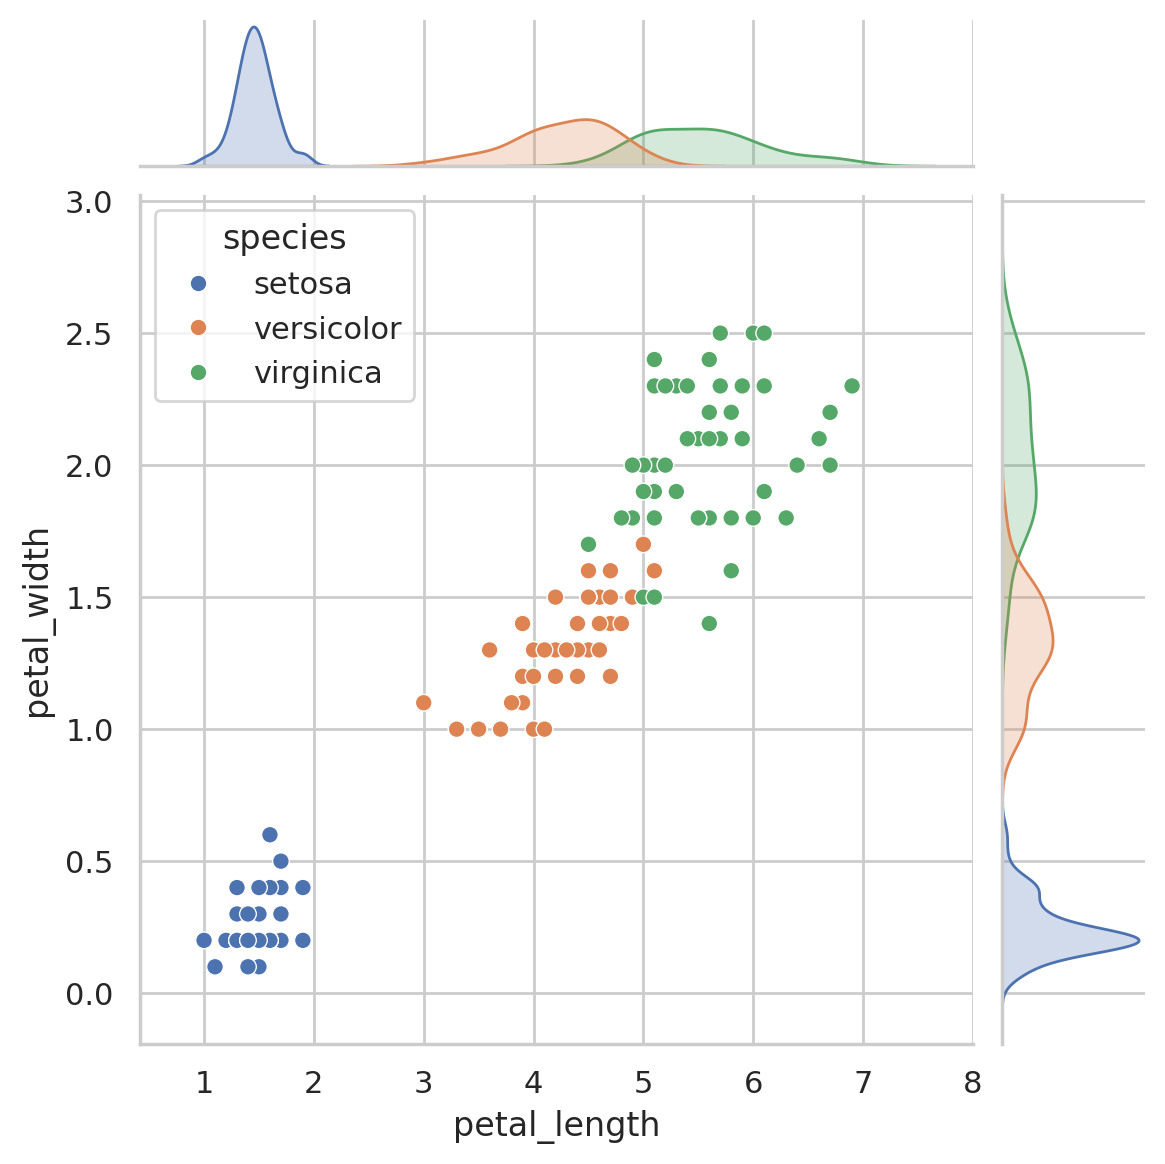

In [60]:
sns.jointplot(x='petal_length', y='petal_width', data=iris, kind='scatter', hue='species')
plt.show()

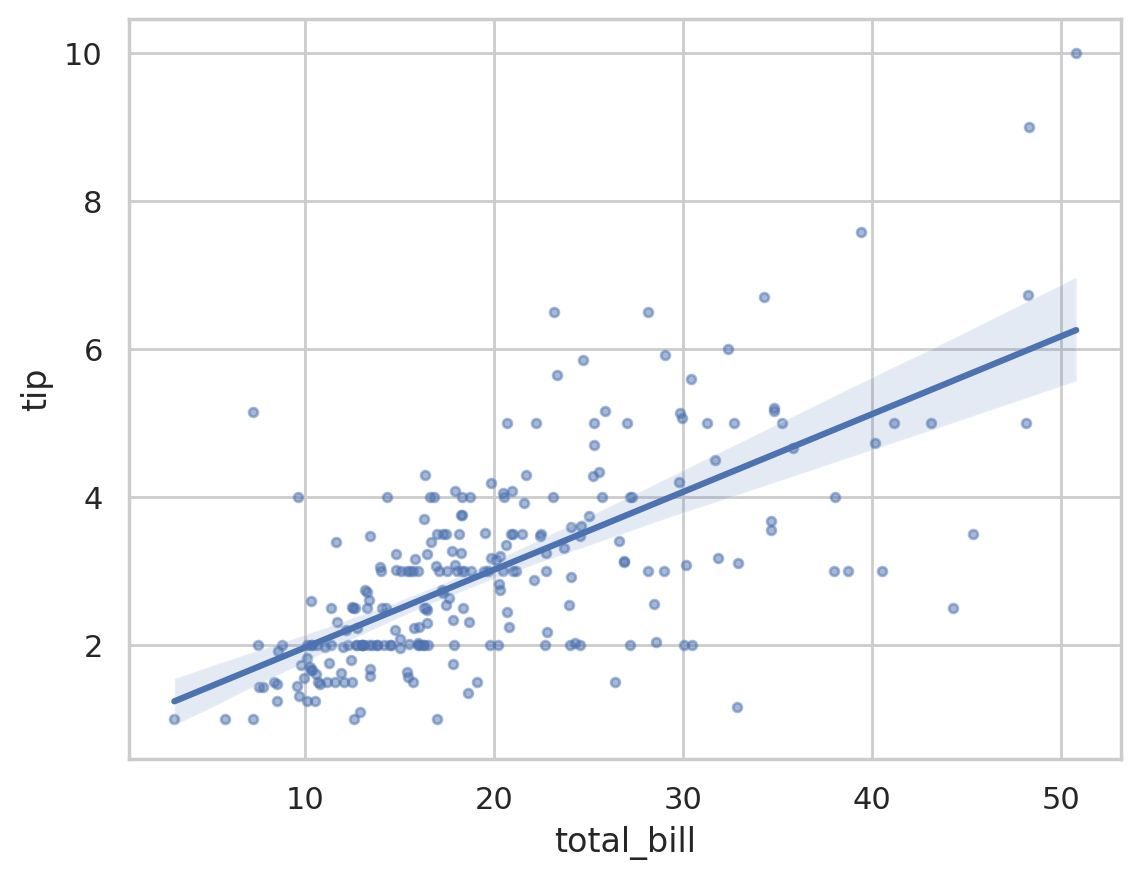

In [74]:
sns.regplot(x='total_bill', y='tip', data=tips, scatter_kws={'s':10, 'alpha':0.5})
plt.show()

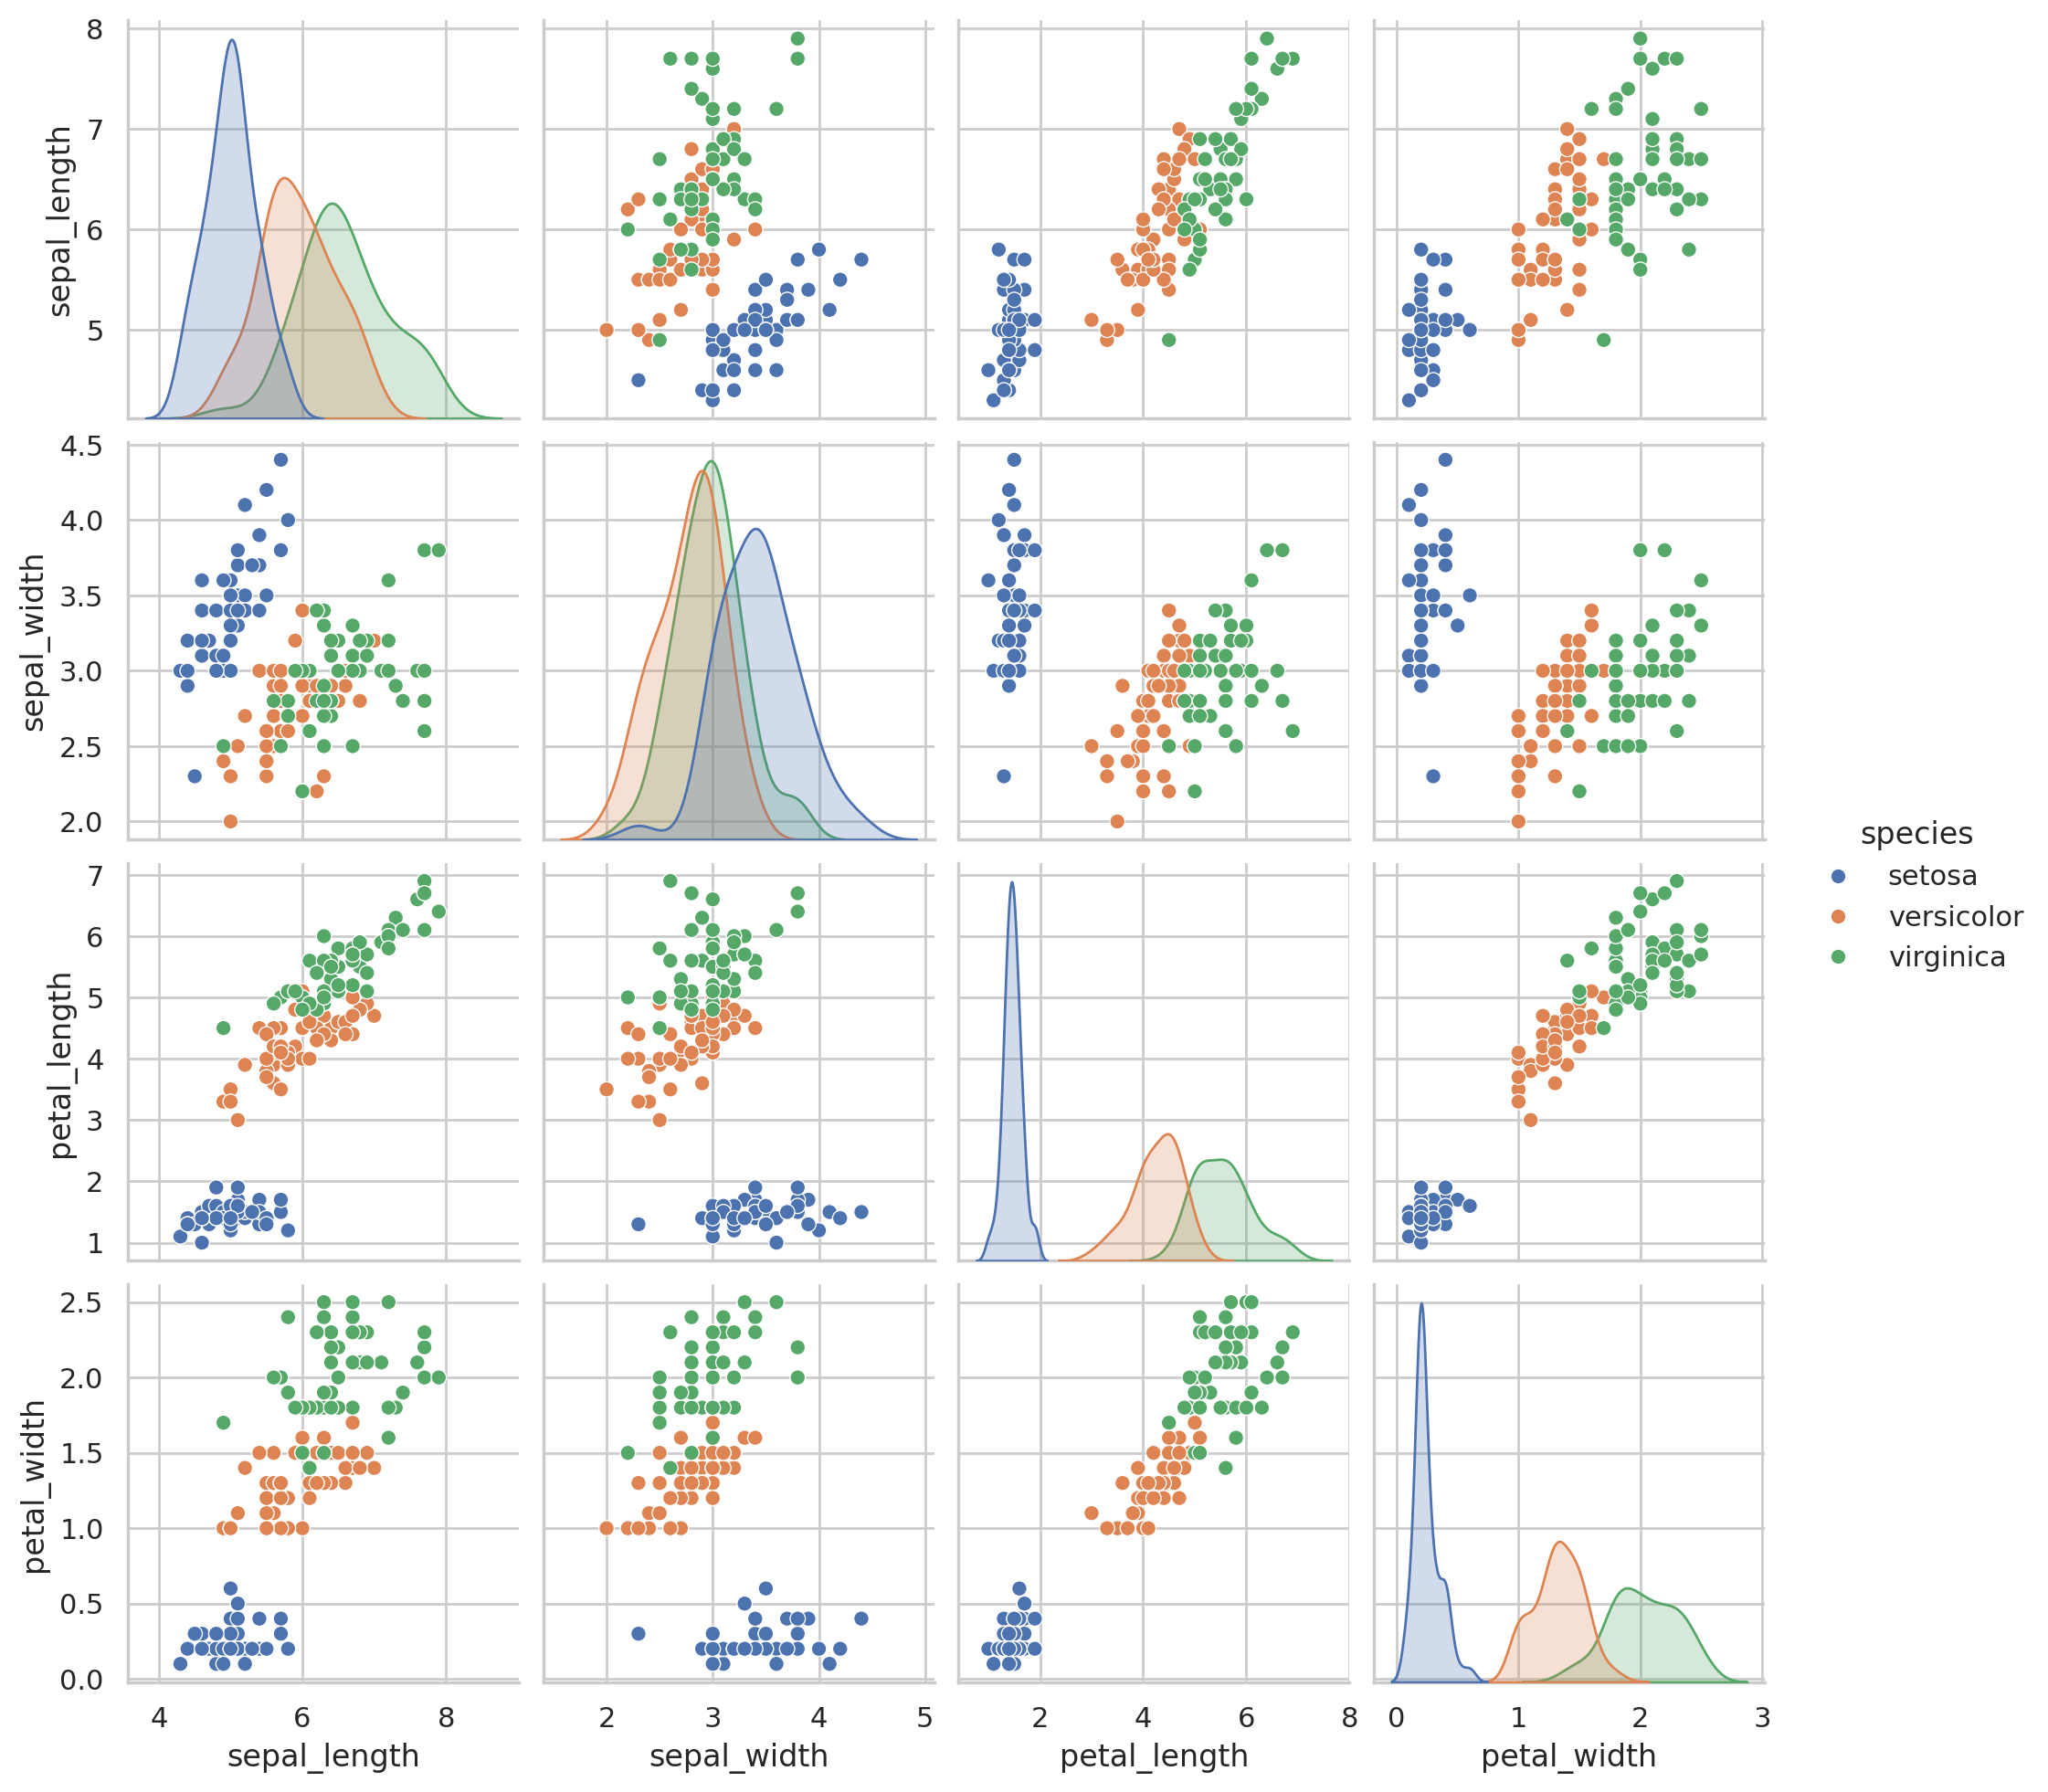

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [82]:
sns.pairplot(iris, hue='species')
plt.show()

iris

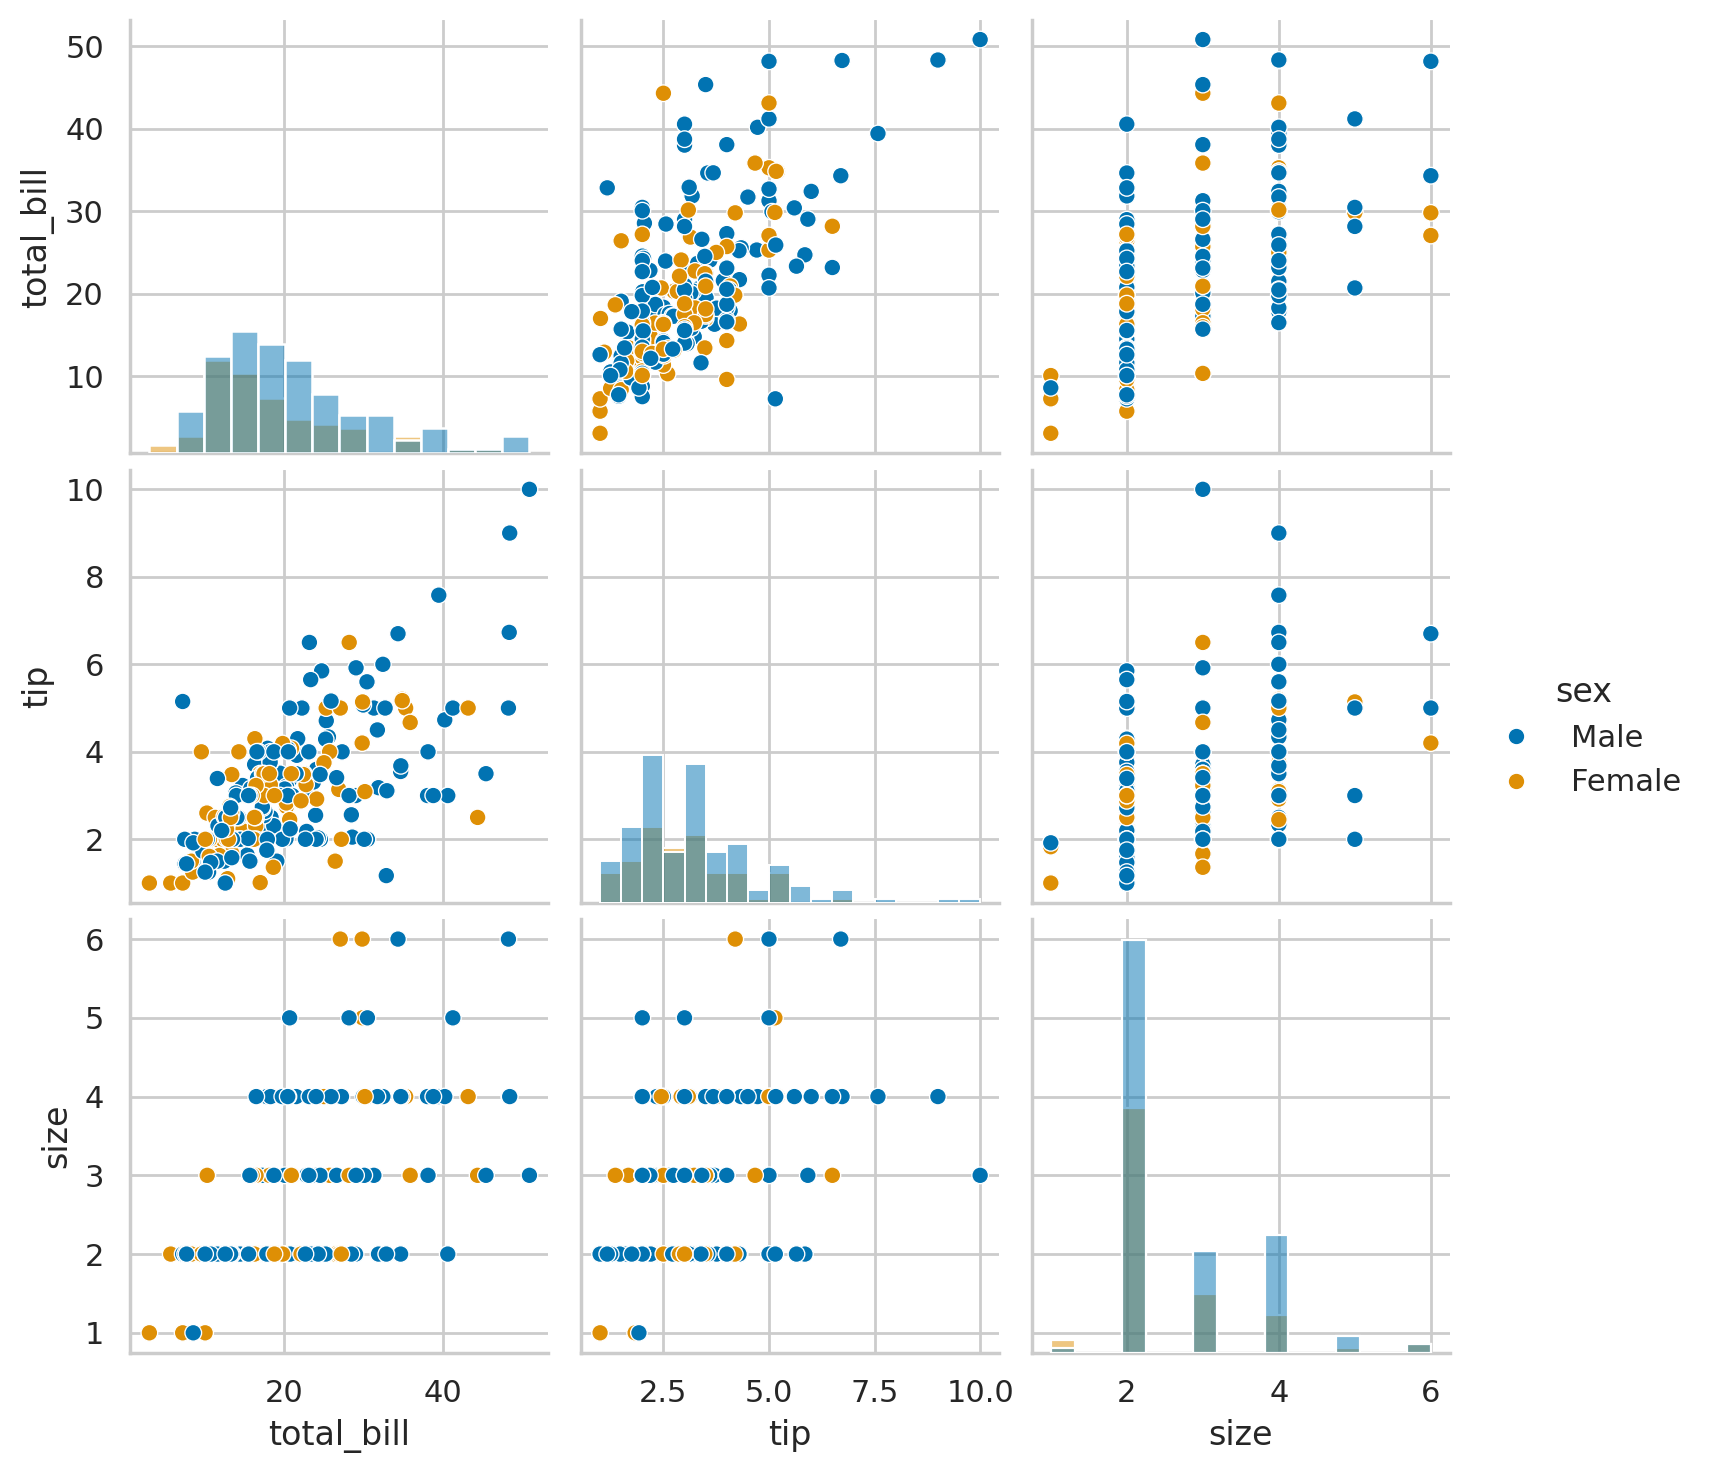

In [79]:
sns.pairplot(tips, hue='sex', diag_kind='hist', palette='colorblind')
plt.show()

2.2.5. heatmap : 두 범주 집계 시각화
https://seaborn.pydata.org/generated/seaborn.heatmap.html

두 범주를 집계한 결과를 색의 농도로 표현해주는 그래프

집계(groupby)와 피봇(pivot)을 먼저 만들어 줘야 한다.

여러 범주를 갖는 변수 비교 시 유용하다.

heatmap( ) 함수 매개변수

data : 히트맵에 사용할 2차원 데이터

annot : 각 셀에 값을 표시할지 여부(기본값:False)

fmt : annot=True일 때 숫자 포맷 설정

cmap : 색상 팔레트 지정

cbar : 컬러바 표시 여부

square : 셀을 정사각형으로 표시

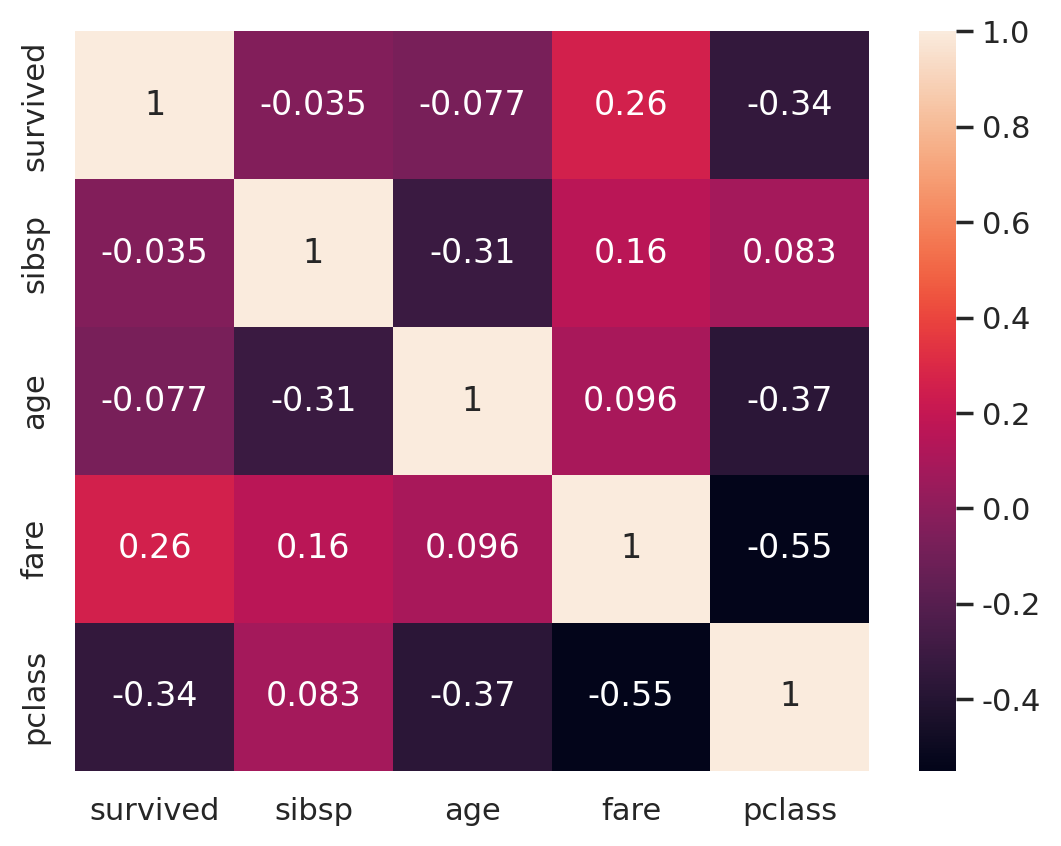

In [ ]:
titanic_corr = titanic[['survived', 'sibsp', 'age', 'fare', 'pclass']].corr()
sns.heatmap(data=titanic_corr, annot=True)
plt.show()

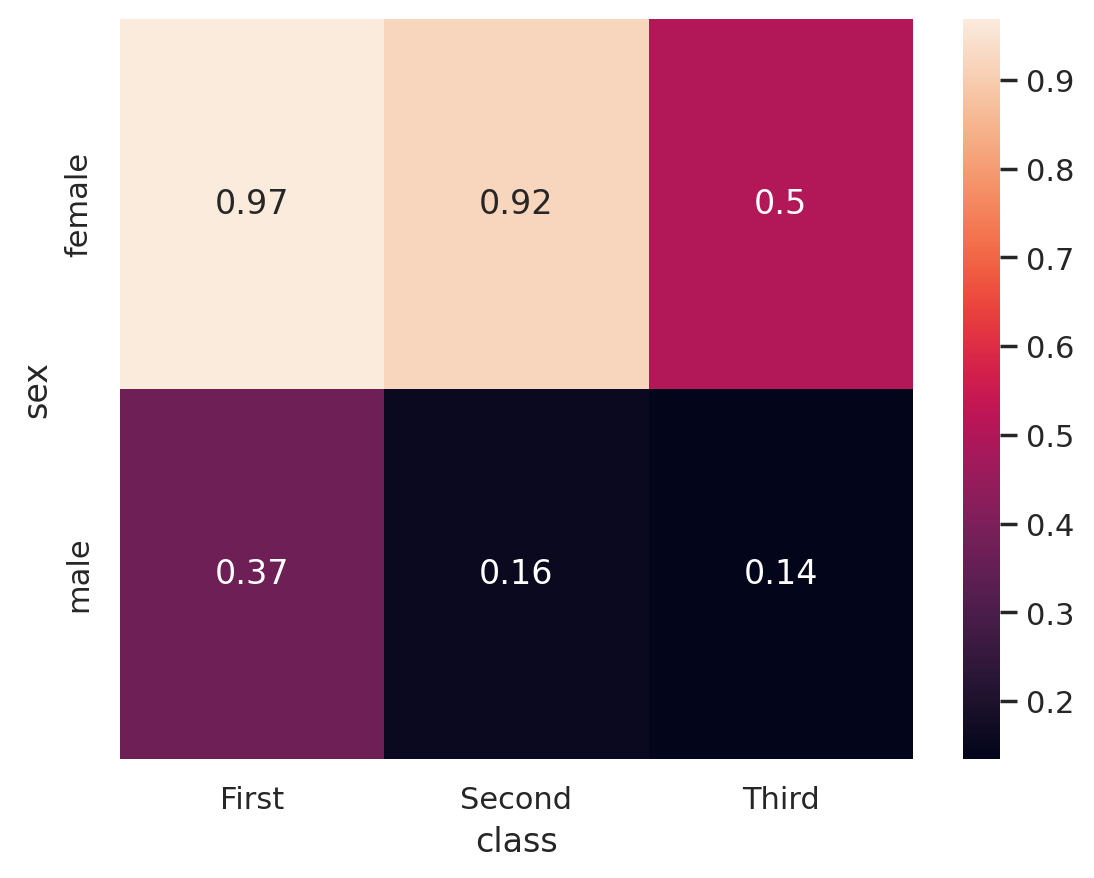

In [83]:
sns.heatmap(data=pd.pivot_table(data=titanic, index='sex', columns='class', values='survived', aggfunc='mean'), annot=True)
plt.show()

In [ ]:
# 타이타닉 데이터로 나이와 운임의 상관관계를 인터랙티브하게 그리기
fig = px.scatter(ttc, x='Age', y='Fare', color='Survived', 
                 hover_data=['Name', 'Pclass'], # 마우스 올리면 나올 정보들
                 title='Interactive Titanic Data')
fig.show()


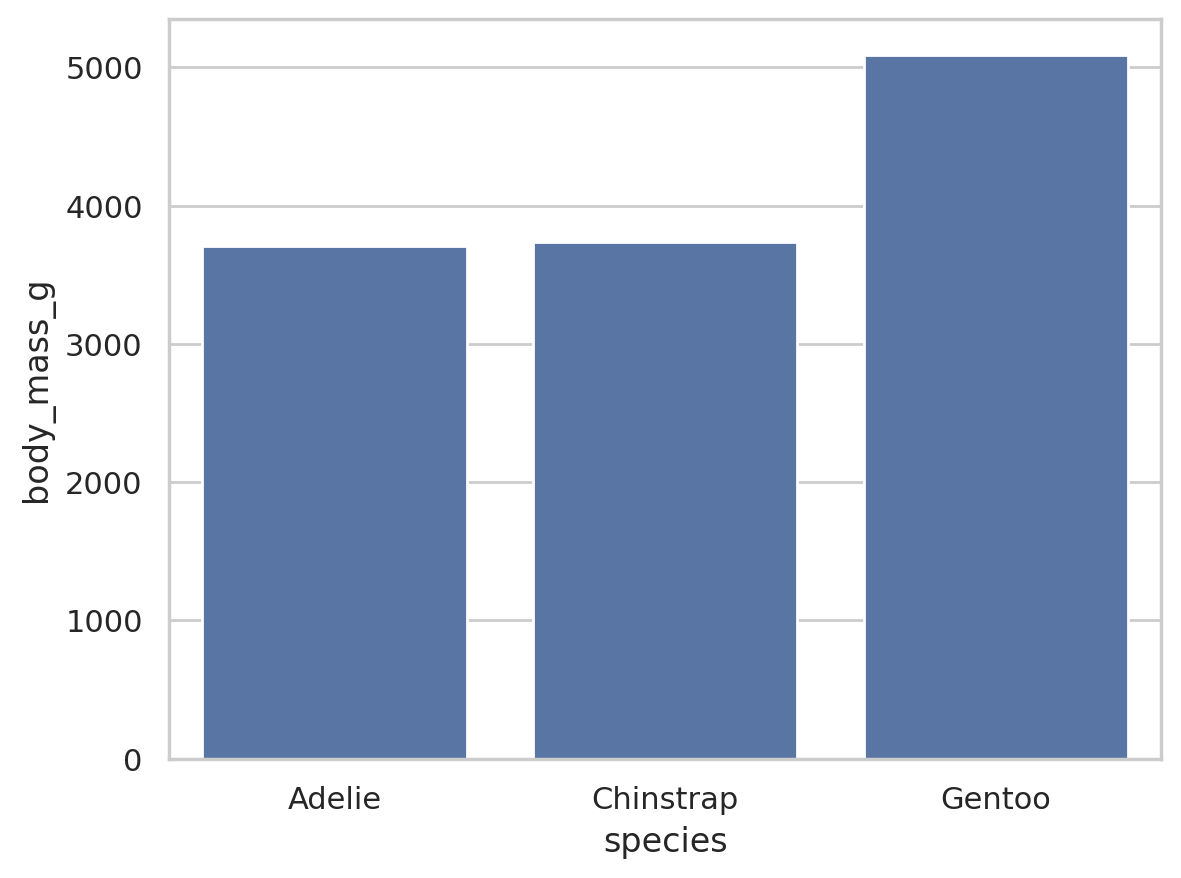

In [92]:
pg = sns.load_dataset('penguins').dropna()

df_groupby = pg.groupby('species')[['body_mass_g']].mean().reset_index()
df_groupby

# seaborn barplot
sns.barplot(data=df_groupby, x='species', y='body_mass_g')
plt.show()

fig = px.bar(df_groupby, x='species', y='body_mass_g')
fig